<a href="https://colab.research.google.com/github/Marina4ij/DS_1_Marina/blob/main/dz2_helpdesk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Фиксируем seed для воспроизводимости результатов
np.random.seed(42)
random.seed(42)

n = 1000 # Количество записей

# 1. Генерация базовых данных
data = {
    'ticket_id': [f"TKT-{i:04d}" for i in range(1, n + 1)],
    'created_date': [datetime.now() - timedelta(days=random.randint(0, 365)) for _ in range(n)],
    'department': np.random.choice(['Продажи', 'Маркетинг', 'Финансы', 'HR', 'Разработка', 'Бухгалтерия', 'Директ'], n),
    'category': np.random.choice(['Оборудование', 'ПО', 'Сеть', 'Доступы', 'Почта', '1С', 'Принтеры'], n),
    'priority': np.random.choice(['Низкий', 'Средний', 'Высокий', 'Критический'], n, p=[0.3, 0.4, 0.2, 0.1]),
    'status': np.random.choice(['Открыта', 'В работе', 'Решена', 'Закрыта'], n, p=[0.1, 0.15, 0.35, 0.4]),
    'is_vip': np.random.choice([True, False], n, p=[0.05, 0.95]) # 5% заявок от VIP
}

df = pd.DataFrame(data)

# 2. Генерация времени решения и оценки (только для решенных заявок)
df['resolution_time_hours'] = np.nan
df['satisfaction_score'] = np.nan # Оценка от 1 до 5

mask_resolved = df['status'].isin(['Решена', 'Закрыта'])

# Зависимость времени решения от приоритета
hours_map = {
    'Низкий': (24, 72),
    'Средний': (8, 24),
    'Высокий': (2, 8),
    'Критический': (0.5, 3)
}

for idx, row in df[mask_resolved].iterrows():
    min_h, max_h = hours_map[row['priority']]
    # Время решения
    df.at[idx, 'resolution_time_hours'] = round(random.uniform(min_h, max_h), 1)
    # Оценка (решенные чаще ставят 4 или 5, но иногда бывает и 3)
    df.at[idx, 'satisfaction_score'] = random.choices([1, 2, 3, 4, 5], weights=[0.02, 0.03, 0.15, 0.4, 0.4])[0]

# 3. Сортировка и сохранение
df = df.sort_values(by='created_date', ascending=False).reset_index(drop=True)

# Сохраняем в CSV
file_name = 'it_helpdesk_tickets.csv'
df.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ Датасет успешно сгенерирован и сохранен в файл '{file_name}'")
print(f"📊 Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head(10)) # Показать первые 10 строк

✅ Датасет успешно сгенерирован и сохранен в файл 'it_helpdesk_tickets.csv'
📊 Размер: 1000 строк, 9 столбцов


,ticket_id,created_date,department,category,priority,status,is_vip,resolution_time_hours,satisfaction_score
0,TKT-0559,2026-06-12 05:15:46.848709,Разработка,ПО,Низкий,Решена,True,41.7,5.0
1,TKT-0522,2026-06-12 05:15:46.848646,Разработка,Принтеры,Средний,В работе,False,NaN,NaN
2,TKT-0180,2026-06-12 05:15:46.848055,HR,Почта,Средний,Решена,False,21.2,5.0
3,TKT-0979,2026-06-11 05:15:46.849496,Финансы,Принтеры,Низкий,Закрыта,False,40.3,5.0
4,TKT-0421,2026-06-11 05:15:46.848468,Продажи,ПО,Средний,Решена,False,14.1,4.0
5,TKT-0303,2026-06-11 05:15:46.848262,Финансы,Оборудование,Средний,В работе,False,NaN,NaN
6,TKT-0163,2026-06-11 05:15:46.848026,Маркетинг,Почта,Высокий,Решена,False,4.0,3.0
7,TKT-0610,2026-06-10 05:15:46.848796,Продажи,ПО,Низкий,Решена,False,59.2,5.0
8,TKT-0683,2026-06-09 05:15:46.848922,Директ,Доступы,Средний,Решена,False,8.3,4.0
9,TKT-0231,2026-06-09 05:15:46.848141,Финансы,ПО,Критический,Решена,False,0.8,4.0


Тема датасета: Заявки в службу IT-поддержки (Helpdesk)

In [11]:
%%writefile config.py
import os

# В Google Colab используем текущую рабочую директорию
BASE_DIR = os.getcwd()

# Пути к папкам с данными
RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")

# Примеры путей к файлам
CSV_FILE_PATH = os.path.join(RAW_DATA_DIR, "it_helpdesk_tickets.csv")
OUTPUT_FILE_PATH = os.path.join(PROCESSED_DATA_DIR, "cleaned_tickets.csv")

# Настройки API (пример)
API_URL = "https://api.example.com/v1/tickets"
API_TIMEOUT = 10

# Автоматически создаем папки, если их нет
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

print(f"✅ config.py создан")
print(f"📁 Базовая директория: {BASE_DIR}")
print(f"📁 RAW_DATA_DIR: {RAW_DATA_DIR}")
print(f"📁 PROCESSED_DATA_DIR: {PROCESSED_DATA_DIR}")

Overwriting config.py


config.py (Конфигурация)Храним все пути, URL и настройки в одном месте.

In [6]:
%%writefile config.py
import os

BASE_DIR = os.getcwd()
RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")

CSV_FILE_PATH = os.path.join(RAW_DATA_DIR, "it_helpdesk_tickets.csv")
OUTPUT_FILE_PATH = os.path.join(PROCESSED_DATA_DIR, "cleaned_tickets.csv")

API_URL = "https://api.example.com/v1/tickets"
API_TIMEOUT = 10

# Автоматически создаем папки
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
print("✅ Файл config.py создан, папки готовы.")

Writing config.py


In [12]:
%%writefile data_loader.py
import pandas as pd
import requests
import logging
from typing import Optional, Dict, Any
import config

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataLoader:
    @staticmethod
    def load_csv(file_path: str) -> pd.DataFrame:
        """Загружает данные из CSV файла."""
        try:
            logging.info(f"Загрузка данных из CSV: {file_path}")
            df = pd.read_csv(file_path, encoding='utf-8-sig')
            logging.info(f"Успешно загружено {len(df)} строк.")
            return df
        except FileNotFoundError:
            logging.error(f"Файл не найден: {file_path}")
            raise
        except pd.errors.EmptyDataError:
            logging.error("Файл CSV пуст.")
            raise
        except Exception as e:
            logging.error(f"Ошибка при загрузке CSV: {e}")
            raise

    @staticmethod
    def load_json(file_path: str) -> pd.DataFrame:
        """Загружает данные из JSON файла."""
        try:
            logging.info(f"Загрузка данных из JSON: {file_path}")
            df = pd.read_json(file_path, encoding='utf-8')
            logging.info(f"Успешно загружено {len(df)} строк.")
            return df
        except Exception as e:
            logging.error(f"Ошибка при загрузке JSON: {e}")
            raise

    @staticmethod
    def load_from_api(url: str, params: Optional[Dict[str, Any]] = None) -> pd.DataFrame:
        """Загружает данные из REST API."""
        try:
            logging.info(f"Запрос данных из API: {url}")
            response = requests.get(url, params=params, timeout=config.API_TIMEOUT)
            response.raise_for_status()

            data = response.json()
            df = pd.DataFrame(data)
            logging.info(f"Успешно загружено {len(df)} строк из API.")
            return df
        except requests.exceptions.RequestException as e:
            logging.error(f"Ошибка запроса к API: {e}")
            raise
        except Exception as e:
            logging.error(f"Ошибка при преобразовании данных API в DataFrame: {e}")
            raise

print("✅ data_loader.py создан")

Writing data_loader.py


data_loader.py (Загрузка данных)
Универсальный загрузчик с обработкой ошибок.

In [13]:
%%writefile data_processing.py
import pandas as pd
import numpy as np
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataProcessor:
    @staticmethod
    def validate_data(df: pd.DataFrame) -> None:
        """Проверяет данные на наличие критических ошибок."""
        logging.info("Начало валидации данных...")

        # 1. Проверка на пустоту
        if df.empty:
            raise ValueError("Датафрейм пуст. Обработка невозможна.")

        # 2. Проверка обязательных колонок
        required_columns = ['ticket_id', 'created_date', 'priority', 'status']
        missing_cols = [col for col in required_columns if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Отсутствуют обязательные колонки: {missing_cols}")

        # 3. Проверка на дубликаты по первичному ключу
        if df['ticket_id'].duplicated().any():
            logging.warning("Обнаружены дубликаты ticket_id. Они будут удалены на этапе очистки.")

        logging.info("Валидация пройдена успешно.")

    @staticmethod
    def clean_data(df: pd.DataFrame) -> pd.DataFrame:
        """Очищает данные от шумов и пропусков."""
        logging.info("Начало очистки данных...")
        df_clean = df.copy()

        # Удаляем полные дубликаты строк
        initial_len = len(df_clean)
        df_clean = df_clean.drop_duplicates(subset=['ticket_id'], keep='first')
        logging.info(f"Удалено дубликатов: {initial_len - len(df_clean)}")

        # Обработка пропусков в числовых колонках (заполняем медианой или 0)
        if 'resolution_time_hours' in df_clean.columns:
            median_time = df_clean['resolution_time_hours'].median()
            df_clean['resolution_time_hours'] = df_clean['resolution_time_hours'].fillna(median_time)

        # Обработка пропусков в категориальных колонках (заполняем 'Unknown')
        for col in df_clean.select_dtypes(include=['object', 'category']).columns:
            df_clean[col] = df_clean[col].fillna('Unknown').astype(str).str.strip()

        logging.info("Очистка данных завершена.")
        return df_clean

    @staticmethod
    def transform_data(df: pd.DataFrame) -> pd.DataFrame:
        """Преобразует данные для дальнейшего анализа или ML."""
        logging.info("Начало трансформации данных...")
        df_transformed = df.copy()

        # 1. Приведение типов данных
        df_transformed['created_date'] = pd.to_datetime(df_transformed['created_date'], errors='coerce')

        # 2. Создание новых признаков (Feature Engineering)
        if 'created_date' in df_transformed.columns:
            df_transformed['day_of_week'] = df_transformed['created_date'].dt.day_name()
            df_transformed['hour_of_day'] = df_transformed['created_date'].dt.hour

        # 3. Кодирование категориальных переменных (пример для priority)
        priority_mapping = {'Низкий': 1, 'Средний': 2, 'Высокий': 3, 'Критический': 4}
        # Заменяем неизвестные значения на 'Средний' (2) перед маппингом
        df_transformed['priority_encoded'] = df_transformed['priority'].map(priority_mapping).fillna(2).astype(int)

        logging.info("Трансформация данных завершена.")
        return df_transformed

Overwriting data_processing.py


data_processing.py (Предобработка и валидация)

In [14]:
%%writefile data_saver.py
import pandas as pd
import logging
import os

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataSaver:
    @staticmethod
    def save_to_csv(df: pd.DataFrame, file_path: str) -> None:
        """Сохраняет DataFrame в CSV."""
        try:
            # Создаем директорию, если её нет
            os.makedirs(os.path.dirname(file_path), exist_ok=True)

            logging.info(f"Сохранение данных в: {file_path}")
            df.to_csv(file_path, index=False, encoding='utf-8-sig')
            logging.info("Данные успешно сохранены.")
        except Exception as e:
            logging.error(f"Ошибка при сохранении CSV: {e}")
            raise

print("✅ data_saver.py создан")

Writing data_saver.py


data_saver.py (Сохранение данных)

In [15]:
%%writefile main.py
import logging
import config
from data_loader import DataLoader
from data_processing import DataProcessor
from data_saver import DataSaver

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("pipeline.log", encoding='utf-8'),
        logging.StreamHandler()
    ]
)

def main():
    logging.info("=== Запуск конвейера обработки данных ===")

    try:
        # 1. ЗАГРУЗКА
        logging.info("Шаг 1: Загрузка данных")
        df_raw = DataLoader.load_csv(config.CSV_FILE_PATH)

        # 2. ВАЛИДАЦИЯ
        logging.info("Шаг 2: Валидация данных")
        DataProcessor.validate_data(df_raw)

        # 3. ОЧИСТКА
        logging.info("Шаг 3: Очистка данных")
        df_cleaned = DataProcessor.clean_data(df_raw)

        # 4. ТРАНСФОРМАЦИЯ
        logging.info("Шаг 4: Трансформация данных")
        df_final = DataProcessor.transform_data(df_cleaned)

        # 5. СОХРАНЕНИЕ
        logging.info("Шаг 5: Сохранение данных")
        DataSaver.save_to_csv(df_final, config.OUTPUT_FILE_PATH)

        logging.info("=== Конвейер успешно завершен ===")

        # Демонстрация результата
        print("\n" + "="*60)
        print("ПЕРВЫЕ 5 СТРОК ОБРАБОТАННЫХ ДАННЫХ:")
        print("="*60)
        display(df_final[['ticket_id', 'priority', 'priority_encoded', 'day_of_week']].head())

    except Exception as e:
        logging.critical(f"Критическая ошибка в конвейере: {e}")
        raise

if __name__ == "__main__":
    main()

Writing main.py


main.py (Оркестрация)

In [16]:
# Сначала убедимся, что у нас есть тестовый CSV файл
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import config

# Генерируем тестовые данные, если файла нет
import os
if not os.path.exists(config.CSV_FILE_PATH):
    print("📊 Генерация тестовых данных...")
    np.random.seed(42)
    random.seed(42)
    n = 1000

    data = {
        'ticket_id': [f"TKT-{i:04d}" for i in range(1, n + 1)],
        'created_date': [datetime.now() - timedelta(days=random.randint(0, 365)) for _ in range(n)],
        'department': np.random.choice(['Продажи', 'Маркетинг', 'Финансы', 'HR', 'Разработка'], n),
        'category': np.random.choice(['Оборудование', 'ПО', 'Сеть', 'Доступы', 'Почта'], n),
        'priority': np.random.choice(['Низкий', 'Средний', 'Высокий', 'Критический'], n, p=[0.3, 0.4, 0.2, 0.1]),
        'status': np.random.choice(['Открыта', 'В работе', 'Решена', 'Закрыта'], n, p=[0.1, 0.15, 0.35, 0.4]),
        'is_vip': np.random.choice([True, False], n, p=[0.05, 0.95])
    }

    df_test = pd.DataFrame(data)

    # Добавляем время решения и оценки
    df_test['resolution_time_hours'] = np.nan
    df_test['satisfaction_score'] = np.nan

    mask_resolved = df_test['status'].isin(['Решена', 'Закрыта'])
    hours_map = {'Низкий': (24, 72), 'Средний': (8, 24), 'Высокий': (2, 8), 'Критический': (0.5, 3)}

    for idx, row in df_test[mask_resolved].iterrows():
        min_h, max_h = hours_map[row['priority']]
        df_test.at[idx, 'resolution_time_hours'] = round(random.uniform(min_h, max_h), 1)
        df_test.at[idx, 'satisfaction_score'] = random.choices([1, 2, 3, 4, 5], weights=[0.02, 0.03, 0.15, 0.4, 0.4])[0]

    df_test.to_csv(config.CSV_FILE_PATH, index=False, encoding='utf-8-sig')
    print(f"✅ Тестовые данные сохранены в {config.CSV_FILE_PATH}")

# Теперь запускаем основной пайплайн
print("\n" + "="*60)
print("ЗАПУСК MAIN.PY")
print("="*60 + "\n")

import main
main.main()

📊 Генерация тестовых данных...
✅ Тестовые данные сохранены в /content/data/raw/it_helpdesk_tickets.csv

ЗАПУСК MAIN.PY

✅ data_loader.py создан
✅ data_saver.py создан

ПЕРВЫЕ 5 СТРОК ОБРАБОТАННЫХ ДАННЫХ:


,ticket_id,priority,priority_encoded,day_of_week
0,TKT-0001,Средний,2,Sunday
1,TKT-0002,Средний,2,Thursday
2,TKT-0003,Низкий,1,Sunday
3,TKT-0004,Средний,2,Friday
4,TKT-0005,Средний,2,Saturday


Запуск всего пайплайна

In [19]:
%%writefile data_visualizer.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, Dict, List, Tuple
import logging
import os

# Настройка стиля для красивых графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataVisualizer:
    """Класс для управления визуализацией данных с возможностью добавления и удаления графиков."""

    def __init__(self):
        self.plots: Dict[str, Tuple[plt.Figure, plt.Axes]] = {}
        logging.info("✅ DataVisualizer инициализирован")

    def add_histogram(self, df: pd.DataFrame, column: str, plot_id: str, bins: int = 30,
                      title: Optional[str] = None, xlabel: Optional[str] = None,
                      ylabel: str = "Частота", color: str = "skyblue", figsize: Tuple[int, int] = (10, 6)) -> None:
        if column not in df.columns:
            raise ValueError(f"Колонка '{column}' не найдена в DataFrame")
        if plot_id in self.plots:
            self.remove_plot(plot_id)

        fig, ax = plt.subplots(figsize=figsize)
        sns.histplot(data=df, x=column, bins=bins, color=color, edgecolor="black", ax=ax, kde=True)

        ax.set_title(title or f"Распределение: {column}", fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel or column, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)

        # Добавляем среднее и медиану
        mean_val = df[column].mean()
        median_val = df[column].median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')
        ax.legend()
        plt.tight_layout()

        self.plots[plot_id] = (fig, ax)
        logging.info(f"✅ Гистограмма '{plot_id}' добавлена")

    def add_line_plot(self, df: pd.DataFrame, x_column: str, y_column: str, plot_id: str,
                      title: Optional[str] = None, xlabel: Optional[str] = None,
                      ylabel: Optional[str] = None, color: str = "blue", figsize: Tuple[int, int] = (12, 6)) -> None:
        if x_column not in df.columns or y_column not in df.columns:
            raise ValueError(f"Колонки '{x_column}' или '{y_column}' не найдены")
        if plot_id in self.plots:
            self.remove_plot(plot_id)

        fig, ax = plt.subplots(figsize=figsize)
        sns.lineplot(data=df, x=x_column, y=y_column, color=color, linewidth=2.0, marker='o', markersize=6, ax=ax)

        ax.set_title(title or f"{y_column} по {x_column}", fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel or x_column, fontsize=12)
        ax.set_ylabel(ylabel or y_column, fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        self.plots[plot_id] = (fig, ax)
        logging.info(f"✅ Линейный график '{plot_id}' добавлен")

    def add_scatter_plot(self, df: pd.DataFrame, x_column: str, y_column: str, plot_id: str,
                         hue_column: Optional[str] = None, title: Optional[str] = None,
                         xlabel: Optional[str] = None, ylabel: Optional[str] = None,
                         color: str = "blue", alpha: float = 0.6, figsize: Tuple[int, int] = (10, 8)) -> None:
        if x_column not in df.columns or y_column not in df.columns:
            raise ValueError(f"Колонки '{x_column}' или '{y_column}' не найдены")
        if plot_id in self.plots:
            self.remove_plot(plot_id)

        fig, ax = plt.subplots(figsize=figsize)
        scatter_params = {'data': df, 'x': x_column, 'y': y_column, 'alpha': alpha, 'ax': ax}

        if hue_column and hue_column in df.columns:
            scatter_params['hue'] = hue_column
            scatter_params['palette'] = 'viridis'
        else:
            scatter_params['color'] = color

        sns.scatterplot(**scatter_params)

        # Добавляем линию тренда
        sns.regplot(data=df, x=x_column, y=y_column, scatter=False, color='red',
                    line_kws={'linestyle': '--', 'linewidth': 2}, ax=ax)

        ax.set_title(title or f"{y_column} vs {x_column}", fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel or x_column, fontsize=12)
        ax.set_ylabel(ylabel or y_column, fontsize=12)
        plt.tight_layout()

        self.plots[plot_id] = (fig, ax)
        logging.info(f"✅ Диаграмма рассеяния '{plot_id}' добавлена")

    def add_bar_chart(self, df: pd.DataFrame, x_column: str, y_column: str, plot_id: str,
                      title: Optional[str] = None, xlabel: Optional[str] = None,
                      ylabel: Optional[str] = None, color: str = "coral", figsize: Tuple[int, int] = (10, 6)) -> None:
        if x_column not in df.columns or y_column not in df.columns:
            raise ValueError(f"Колонки '{x_column}' или '{y_column}' не найдены")
        if plot_id in self.plots:
            self.remove_plot(plot_id)

        fig, ax = plt.subplots(figsize=figsize)
        sns.barplot(data=df, x=x_column, y=y_column, color=color, ax=ax)

        ax.set_title(title or f"{y_column} по {x_column}", fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel or x_column, fontsize=12)
        ax.set_ylabel(ylabel or y_column, fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        self.plots[plot_id] = (fig, ax)
        logging.info(f"✅ Столбчатая диаграмма '{plot_id}' добавлена")

    def remove_plot(self, plot_id: str) -> None:
        if plot_id not in self.plots:
            logging.warning(f"График с ID '{plot_id}' не найден")
            return
        fig, ax = self.plots[plot_id]
        plt.close(fig)
        del self.plots[plot_id]
        logging.info(f"🗑️ График '{plot_id}' удален")

    def clear_all(self) -> None:
        plot_ids = list(self.plots.keys())
        for plot_id in plot_ids:
            self.remove_plot(plot_id)
        logging.info("🧹 Все графики удалены")

    def show_plot(self, plot_id: str) -> None:
        if plot_id not in self.plots:
            logging.error(f"График с ID '{plot_id}' не найден")
            return
        fig, ax = self.plots[plot_id]
        plt.show()

    def show_all(self) -> None:
        if not self.plots:
            logging.warning("Нет графиков для отображения")
            return
        logging.info(f"📊 Отображение {len(self.plots)} графиков...")
        for plot_id, (fig, ax) in self.plots.items():
            logging.info(f"Показ графика: {plot_id}")
            plt.show()

    def get_plot_ids(self) -> List[str]:
        return list(self.plots.keys())

    def save_plot(self, plot_id: str, filepath: str, dpi: int = 300) -> None:
        if plot_id not in self.plots:
            logging.error(f"График с ID '{plot_id}' не найден")
            return
        fig, ax = self.plots[plot_id]
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        logging.info(f"💾 График '{plot_id}' сохранен в {filepath}")

print("✅ Файл data_visualizer.py успешно создан в Colab!")

Overwriting data_visualizer.py


data_visualizer.py (Модуль визуализации)

✅ Файл data_visualizer.py успешно создан в Colab!

ДОБАВЛЕНИЕ ГРАФИКОВ

📋 Текущие графики в памяти: ['hist_time', 'line_daily', 'scatter_sat', 'bar_priority']

ОТОБРАЖЕНИЕ ВСЕХ ГРАФИКОВ (прокрутите вниз)


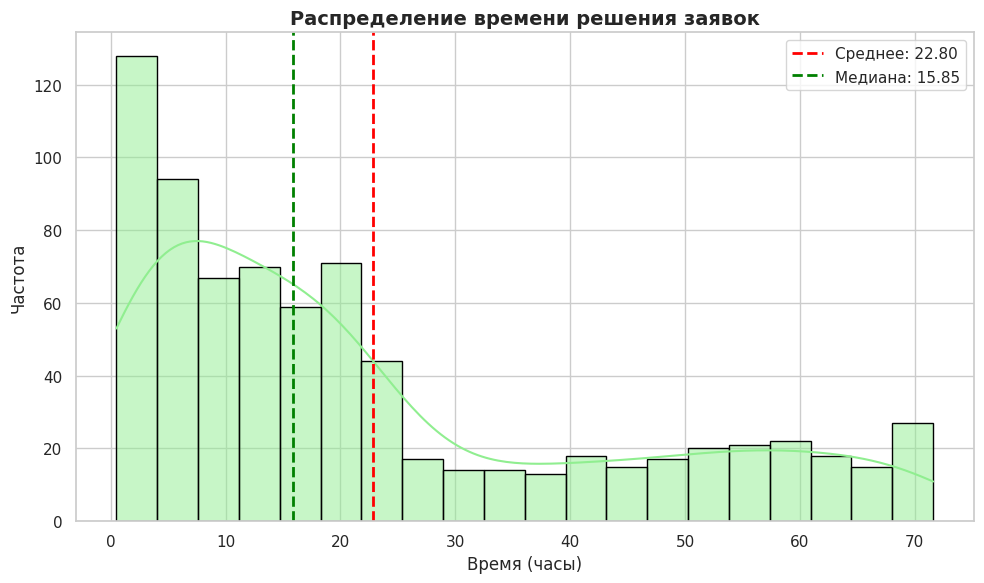

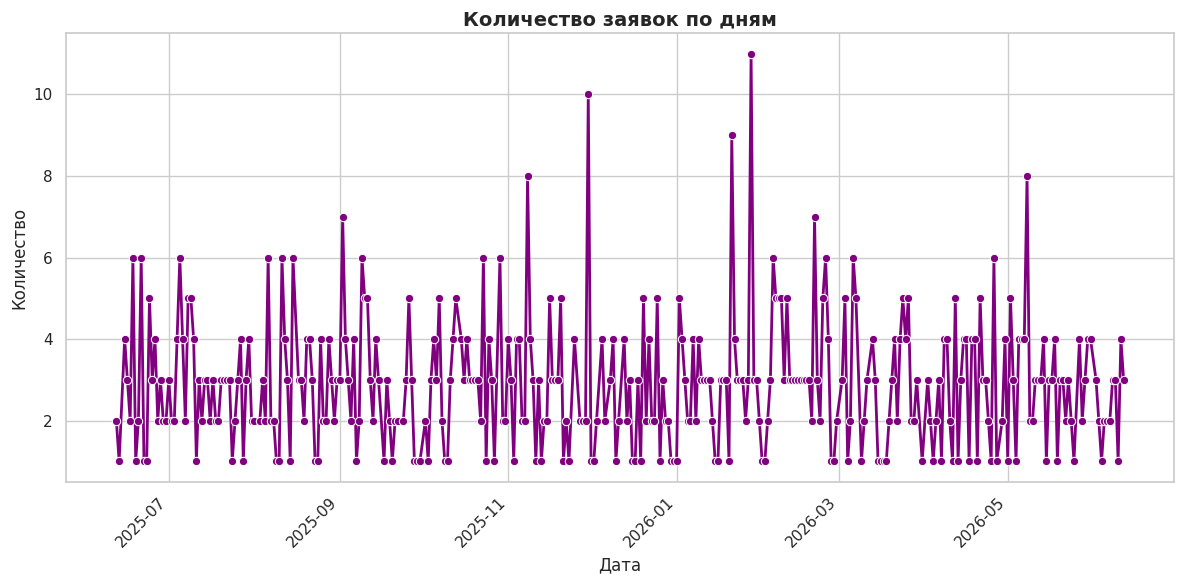

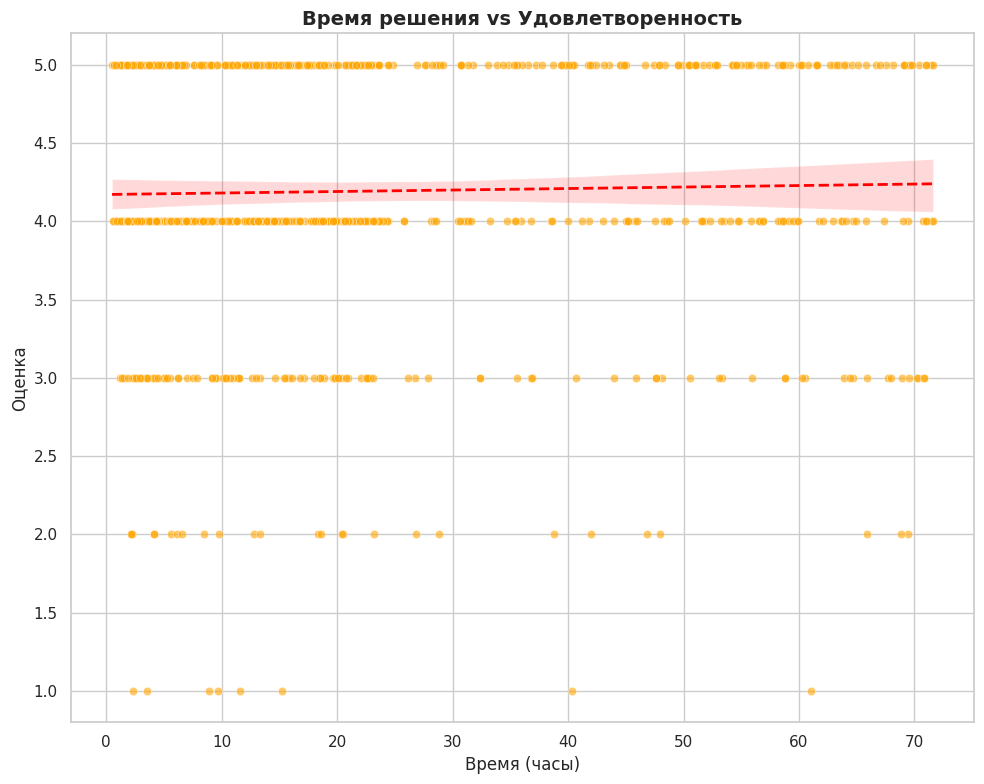

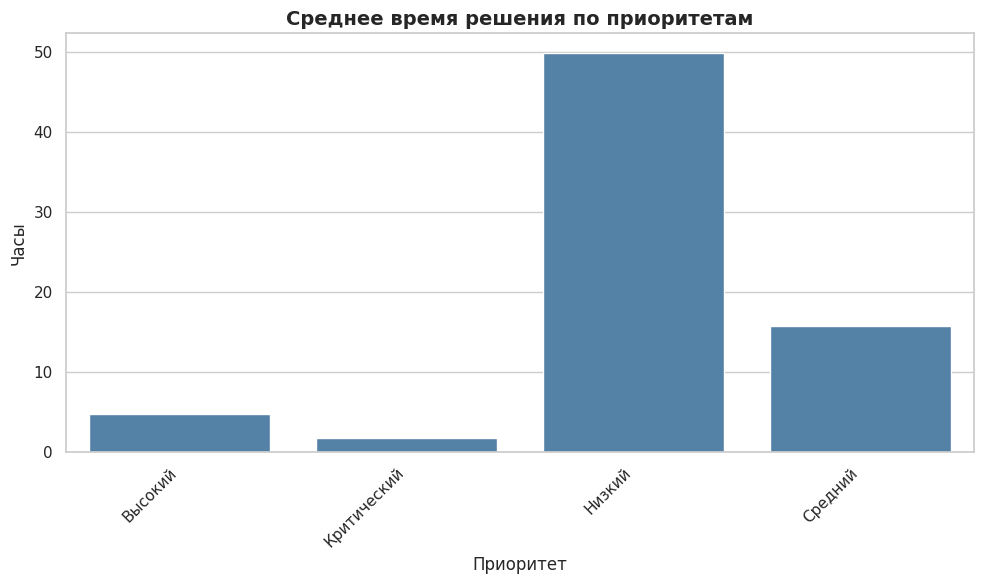


СОХРАНЕНИЕ И УДАЛЕНИЕ
💾 График 'line_daily' сохранен как daily_tickets_chart.png (проверьте папку слева 📁)
📋 Графики после удаления: ['line_daily', 'scatter_sat', 'bar_priority']
📋 Графики после полной очистки: []


In [20]:
 import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import os
from data_visualizer import DataVisualizer

# 1. ГЕНЕРАЦИЯ ТЕСТОВЫХ ДАННЫХ (чтобы код гарантированно работал в Colab)
csv_path = "it_helpdesk_tickets.csv"
if not os.path.exists(csv_path):
    print("📊 Генерация тестовых данных...")
    np.random.seed(42)
    n = 500 # Уменьшим до 500 для быстрой отрисовки scatter plot

    data = {
        'ticket_id': [f"TKT-{i:04d}" for i in range(1, n + 1)],
        'created_date': [datetime.now() - timedelta(days=random.randint(0, 90)) for _ in range(n)],
        'priority': np.random.choice(['Низкий', 'Средний', 'Высокий', 'Критический'], n, p=[0.3, 0.4, 0.2, 0.1]),
        'status': np.random.choice(['Открыта', 'В работе', 'Решена', 'Закрыта'], n, p=[0.1, 0.15, 0.35, 0.4]),
        'resolution_time_hours': np.random.uniform(1, 48, n),
        'satisfaction_score': np.random.choice([1, 2, 3, 4, 5], n, p=[0.02, 0.03, 0.15, 0.4, 0.4])
    }
    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"✅ Данные сохранены в {csv_path}")
else:
    df = pd.read_csv(csv_path, encoding='utf-8-sig')

# Приводим даты к правильному формату
df['created_date'] = pd.to_datetime(df['created_date'])

# 2. ИНИЦИАЛИЗАЦИЯ ВИЗУАЛИЗАТОРА
viz = DataVisualizer()

print("\n" + "="*60)
print("ДОБАВЛЕНИЕ ГРАФИКОВ")
print("="*60)

# 1. Гистограмма
viz.add_histogram(
    df=df, column='resolution_time_hours', plot_id='hist_time',
    bins=20, title='Распределение времени решения заявок', xlabel='Время (часы)', color='lightgreen'
)

# 2. Линейный график (агрегация по дням)
daily_tickets = df.groupby(df['created_date'].dt.date).size().reset_index(name='count')
daily_tickets.columns = ['date', 'count']
viz.add_line_plot(
    df=daily_tickets, x_column='date', y_column='count', plot_id='line_daily',
    title='Количество заявок по дням', xlabel='Дата', ylabel='Количество', color='purple'
)

# 3. Диаграмма рассеяния
viz.add_scatter_plot(
    df=df, x_column='resolution_time_hours', y_column='satisfaction_score', plot_id='scatter_sat',
    title='Время решения vs Удовлетворенность', xlabel='Время (часы)', ylabel='Оценка', color='orange'
)

# 4. Столбчатая диаграмма
priority_avg = df.groupby('priority')['resolution_time_hours'].mean().reset_index()
viz.add_bar_chart(
    df=priority_avg, x_column='priority', y_column='resolution_time_hours', plot_id='bar_priority',
    title='Среднее время решения по приоритетам', xlabel='Приоритет', ylabel='Часы', color='steelblue'
)

print(f"\n📋 Текущие графики в памяти: {viz.get_plot_ids()}")

print("\n" + "="*60)
print("ОТОБРАЖЕНИЕ ВСЕХ ГРАФИКОВ (прокрутите вниз)")
print("="*60)
viz.show_all()

print("\n" + "="*60)
print("СОХРАНЕНИЕ И УДАЛЕНИЕ")
print("="*60)
# Сохраняем один график в файл Colab
viz.save_plot('line_daily', 'daily_tickets_chart.png')
print("💾 График 'line_daily' сохранен как daily_tickets_chart.png (проверьте папку слева 📁)")

# Удаляем гистограмму
viz.remove_plot('hist_time')
print(f"📋 Графики после удаления: {viz.get_plot_ids()}")

# Очищаем всё
viz.clear_all()
print(f"📋 Графики после полной очистки: {viz.get_plot_ids()}")

In [21]:
%%writefile data_processor.py
import pandas as pd
import numpy as np
import logging
from typing import Dict, Any

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataProcessor:
    # ... (предыдущие методы validate_data, clean_data, transform_data остаются здесь) ...

    @staticmethod
    def get_missing_counts(df: pd.DataFrame) -> pd.Series:
        """Возвращает количество пропущенных значений в каждом столбце."""
        return df.isnull().sum()

    @staticmethod
    def generate_missing_report(df: pd.DataFrame) -> pd.DataFrame:
        """
        Генерирует подробный отчет о пропущенных значениях.
        Возвращает DataFrame с колонками: Missing_Count, Missing_Percent, Data_Type.
        """
        logging.info("Генерация отчета о пропущенных значениях...")

        missing_counts = df.isnull().sum()
        missing_percent = (missing_counts / len(df)) * 100
        dtypes = df.dtypes

        report = pd.DataFrame({
            'Missing_Count': missing_counts,
            'Missing_Percent': missing_percent.round(2),
            'Data_Type': dtypes
        })

        # Сортируем по проценту пропусков по убыванию для удобства
        report = report.sort_values(by='Missing_Percent', ascending=False)

        # Фильтруем, чтобы показать только те столбцы, где есть пропуски (опционально)
        # report = report[report['Missing_Count'] > 0]

        logging.info("Отчет успешно сгенерирован.")
        return report

    @staticmethod
    def fill_missing_values(df: pd.DataFrame, strategies: Dict[str, str]) -> pd.DataFrame:
        """
        Заполняет пропущенные значения в указанных столбцах согласно стратегиям.

        Args:
            df: Исходный DataFrame.
            strategies: Словарь вида {'имя_колонки': 'стратегия'}.
                      Поддерживаемые стратегии: 'mean', 'median', 'mode', 'forward_fill', 'backward_fill'.

        Returns:
            DataFrame с заполненными пропусками.
        """
        logging.info("Начало заполнения пропущенных значений...")
        df_filled = df.copy()

        for col, strategy in strategies.items():
            if col not in df_filled.columns:
                logging.warning(f"Колонка '{col}' не найдена в DataFrame. Пропуск.")
                continue

            if df_filled[col].isnull().sum() == 0:
                logging.info(f"Колонка '{col}' не имеет пропусков. Пропуск.")
                continue

            try:
                if strategy == 'mean':
                    if not pd.api.types.is_numeric_dtype(df_filled[col]):
                        raise TypeError(f"Стратегия 'mean' применима только к числовым данным. Колонка '{col}' имеет тип {df_filled[col].dtype}")
                    fill_value = df_filled[col].mean()
                    df_filled[col] = df_filled[col].fillna(fill_value)
                    logging.info(f"Колонка '{col}' заполнена средним значением: {fill_value:.2f}")

                elif strategy == 'median':
                    if not pd.api.types.is_numeric_dtype(df_filled[col]):
                        raise TypeError(f"Стратегия 'median' применима только к числовым данным. Колонка '{col}' имеет тип {df_filled[col].dtype}")
                    fill_value = df_filled[col].median()
                    df_filled[col] = df_filled[col].fillna(fill_value)
                    logging.info(f"Колонка '{col}' заполнена медианой: {fill_value:.2f}")

                elif strategy == 'mode':
                    # mode() возвращает Series, берем первое значение [0]
                    fill_value = df_filled[col].mode()[0]
                    df_filled[col] = df_filled[col].fillna(fill_value)
                    logging.info(f"Колонка '{col}' заполнена модой (наиболее частым значением): {fill_value}")

                elif strategy == 'forward_fill':
                    df_filled[col] = df_filled[col].ffill()
                    logging.info(f"Колонка '{col}' заполнена методом прямого заполнения (ffill).")

                elif strategy == 'backward_fill':
                    df_filled[col] = df_filled[col].bfill()
                    logging.info(f"Колонка '{col}' заполнена методом обратного заполнения (bfill).")

                else:
                    raise ValueError(f"Неизвестная стратегия '{strategy}' для колонки '{col}'")

            except Exception as e:
                logging.error(f"Ошибка при обработке колонки '{col}': {e}")
                raise

        logging.info("Заполнение пропущенных значений завершено.")
        return df_filled

print("✅ Файл data_processor.py успешно обновлен новыми методами!")

Writing data_processor.py


перезапишет предыдущую версию файла, добавив новые методы.

In [22]:
import pandas as pd
import numpy as np
from data_processor import DataProcessor

# 1. СОЗДАНИЕ "ГРЯЗНЫХ" ДАННЫХ ДЛЯ ТЕСТА
print("="*60)
print("1. СОЗДАНИЕ ТЕСТОВЫХ ДАННЫХ С ПРОПУСКАМИ")
print("="*60)

data = {
    'employee_id': [1, 2, 3, 4, 5, 6],
    'age': [25, np.nan, 30, 35, np.nan, 28],          # Числовые пропуски
    'salary': [50000, 60000, np.nan, 80000, 75000, np.nan], # Числовые пропуски
    'department': ['IT', 'HR', 'IT', np.nan, 'HR', 'IT'],   # Категориальные пропуски
    'satisfaction': [4, 5, np.nan, 4, 5, 3]            # Числовые пропуски
}

df_dirty = pd.DataFrame(data)
print("Исходный DataFrame:")
display(df_dirty)

# 2. ГЕНЕРАЦИЯ ОТЧЕТА О ПРОПУСКАХ
print("\n" + "="*60)
print("2. ОТЧЕТ О ПРОПУЩЕННЫХ ЗНАЧЕНИЯХ")
print("="*60)

report = DataProcessor.generate_missing_report(df_dirty)
display(report)

# 3. ЗАПОЛНЕНИЕ ПРОПУСКОВ РАЗНЫМИ СТРАТЕГИЯМИ
print("\n" + "="*60)
print("3. ПРИМЕНЕНИЕ СТРАТЕГИЙ ЗАПОЛНЕНИЯ")
print("="*60)

# Определяем стратегии для каждой колонки
fill_strategies = {
    'age': 'median',          # Возраст лучше заполнять медианой (устойчива к выбросам)
    'salary': 'mean',         # Зарплату заполним средним (для примера)
    'department': 'mode',     # Отдел заполним самым частым значением (категориальный признак)
    'satisfaction': 'forward_fill' # Удовлетворенность заполним предыдущим значением
}

df_clean = DataProcessor.fill_missing_values(df_dirty, strategies=fill_strategies)

# 4. ПРОВЕРКА РЕЗУЛЬТАТА
print("\n" + "="*60)
print("4. ИТОГОВЫЙ DATAFRAME ПОСЛЕ ОЧИСТКИ")
print("="*60)
display(df_clean)

# Финальная проверка: пропусков быть не должно
final_check = DataProcessor.get_missing_counts(df_clean)
print("\n✅ Финальная проверка пропусков (должны быть одни нули):")
print(final_check)

✅ Файл data_processor.py успешно обновлен новыми методами!
1. СОЗДАНИЕ ТЕСТОВЫХ ДАННЫХ С ПРОПУСКАМИ
Исходный DataFrame:


,employee_id,age,salary,department,satisfaction
0,1,25.0,50000.0,IT,4.0
1,2,NaN,60000.0,HR,5.0
2,3,30.0,NaN,IT,NaN
3,4,35.0,80000.0,NaN,4.0
4,5,NaN,75000.0,HR,5.0
5,6,28.0,NaN,IT,3.0



2. ОТЧЕТ О ПРОПУЩЕННЫХ ЗНАЧЕНИЯХ


,Missing_Count,Missing_Percent,Data_Type
age,2,33.33,float64
salary,2,33.33,float64
department,1,16.67,object
satisfaction,1,16.67,float64
employee_id,0,0.00,int64



3. ПРИМЕНЕНИЕ СТРАТЕГИЙ ЗАПОЛНЕНИЯ

4. ИТОГОВЫЙ DATAFRAME ПОСЛЕ ОЧИСТКИ


,employee_id,age,salary,department,satisfaction
0,1,25.0,50000.0,IT,4.0
1,2,29.0,60000.0,HR,5.0
2,3,30.0,66250.0,IT,5.0
3,4,35.0,80000.0,IT,4.0
4,5,29.0,75000.0,HR,5.0
5,6,28.0,66250.0,IT,3.0



✅ Финальная проверка пропусков (должны быть одни нули):
employee_id     0
age             0
salary          0
department      0
satisfaction    0
dtype: int64


создадим "грязный" DataFrame с преднамеренными пропусками, сгенерируем отчет и применим разные стратегии заполнения.